<a href="https://colab.research.google.com/github/sydney142/databases_analytics_assignment/blob/main/Assignment_R_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Install required packages
#install.packages(c("RCurl","tidyverse","sqldf","broom"))
install.packages(c("RCurl", "sqldf", "tidyverse"))


# Load libraries
library(RCurl)
library(tidyverse)
library(sqldf)
#library(broom)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::complete() masks RCurl::complete()
✖ dplyr::filter()   masks stats::filter()
✖ dplyr::lag()      masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [17]:
# read files
orders_df <- read.csv("/content/orders.csv")
deliveries_df <- read.csv("/content/deliveries.csv")
complaints_df <- read.csv("/content/complaints.csv")
customers_df <- read.csv("/content/customers.csv")
incidents_df <- read.csv("/content/incidents.csv")
app_events_df <- read.csv("/content/app_events.csv")
vehicles_df <- read.csv("/content/vehicles.csv")
drivers_df <- read.csv("/content/drivers.csv")

dropoff zone grouping by total order value

In [3]:
sqldf("
SELECT dropoff_zone, SUM(order_value)
FROM orders_df
GROUP BY dropoff_zone
")

dropoff_zone,SUM(order_value)
<chr>,<dbl>
AIRPORT,7733.40
Airport,7341.60
CENTRAL,6825.35
Central,5924.66
Ctr,5599.47
EAST,7262.22
East,6592.96
NORTH,5314.45
North,5278.91


The inconsistent data labelling makes this difficult to read.

# **Order Value Analysis**

Average order value by booking channel

In [4]:
sqldf("
SELECT booking_channel, AVG(order_value)
FROM orders_df
GROUP BY booking_channel
")

booking_channel,AVG(order_value)
<chr>,<dbl>
,88.86160
API,86.39359
App,91.61030
Phone,88.01202
Web,93.94346


In [5]:
mean(orders_df$order_value)
max(orders_df$order_value)
min(orders_df$order_value)

[1] 91.05052

[1] 510.06

[1] 2.04

# **Plots**

In [18]:
library(ggplot2)

Booking channel distribution

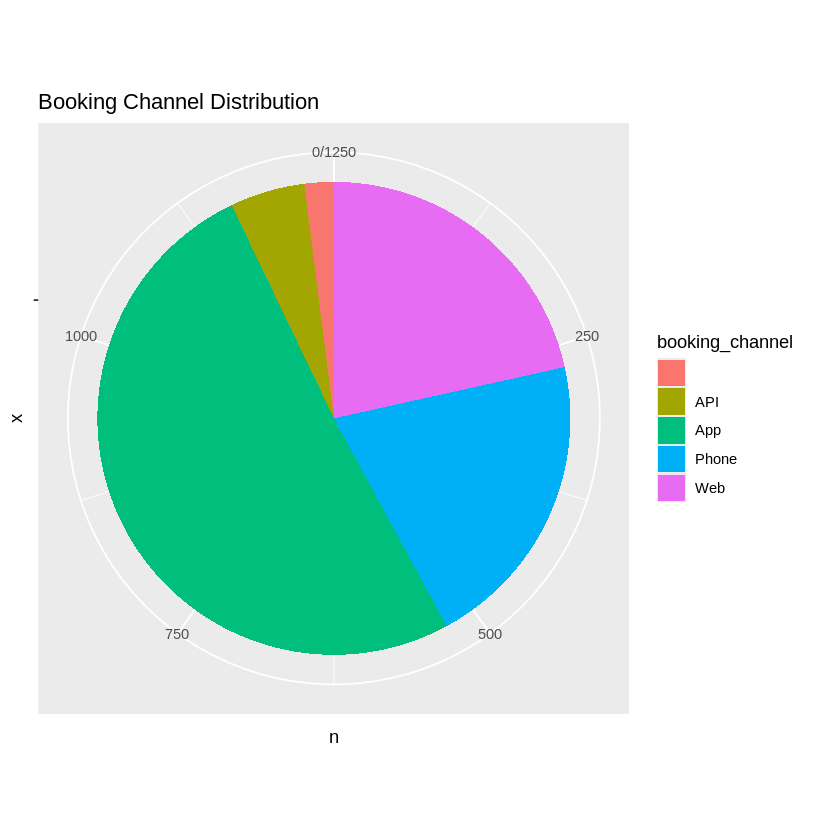

In [19]:
orders_df %>%
  count(booking_channel) %>%
  ggplot(aes(x = "", y = n, fill = booking_channel)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Booking Channel Distribution")

delivery status distribution

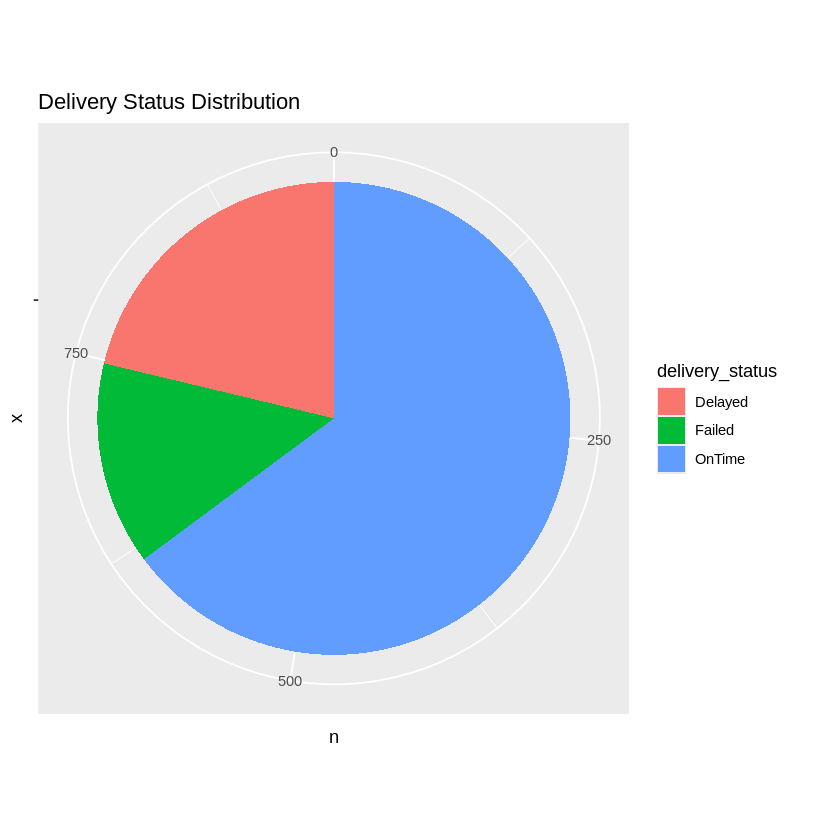

In [20]:
deliveries_df %>%
  count(delivery_status) %>%
  ggplot(aes(x = "", y = n, fill = delivery_status)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Delivery Status Distribution")

A significant proportion of deliveries are failed or delayed.

# **Examining cost of failed or delayed deliveries**

Total compensation awarded for each complaint type

In [8]:
sqldf("
SELECT complaint_type, SUM(compensation_amount)
FROM complaints_df
GROUP BY complaint_type
")

complaint_type,SUM(compensation_amount)
<chr>,<dbl>
AppIssue,980.72
Billing,381.94
Damage,359.73
Delay,1696.84
DriverBehaviour,973.06
MissedPickup,1423.40
SupportExperience,342.50


Delay and missed pickup are the two highest categories.

Average compensation awarded for each complaint type.

In [9]:
sqldf("
SELECT complaint_type, AVG(compensation_amount)
FROM complaints_df
GROUP BY complaint_type
")

complaint_type,AVG(compensation_amount)
<chr>,<dbl>
AppIssue,19.61440
Billing,23.87125
Damage,23.98200
Delay,18.05149
DriverBehaviour,21.15348
MissedPickup,22.59365
SupportExperience,17.12500


Total compensation awarded for delayed or failed deliveries

In [10]:
sqldf("
SELECT SUM(compensation_amount)
FROM complaints_df
WHERE complaint_type = 'Delay' OR complaint_type = 'MissedPickup'")

SUM(compensation_amount)
<dbl>
3120.24


Total compensation awarded

In [11]:
sqldf("
SELECT SUM(compensation_amount)
FROM complaints_df")

SUM(compensation_amount)
<dbl>
6158.19


In [12]:
summary(complaints_df)

    complaint_id    customer_id       order_id     complaint_type
 Length   :320   Length   :320   Length   :320   Length   :320   
 N.unique :320   N.unique :233   N.unique :285   N.unique :  7   
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0   
 Min.nchar:  6   Min.nchar:  5   Min.nchar:  6   Min.nchar:  5   
 Max.nchar:  6   Max.nchar:  5   Max.nchar:  6   Max.nchar: 17   
                                                                 
                                                                 
      channel         severity       created_at        status   
 Length   :320   Length   :320   Length   :320   Length   :320  
 N.unique :  4   N.unique :  3   N.unique :317   N.unique :  4  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  3   Min.nchar:  3   Min.nchar: 19   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar: 19   Max.nchar: 16  
                                                                
                 

In [13]:
sqldf("
SELECT complaint_type, COUNT(complaint_type)
FROM complaints_df
WHERE severity = 'High' or severity = 'Medium'
GROUP BY complaint_type
")

complaint_type,COUNT(complaint_type)
<chr>,<int>
AppIssue,38
Billing,13
Damage,9
Delay,74
DriverBehaviour,47
MissedPickup,53
SupportExperience,15


Of high and medium severity complaints, delay and missed pickup are the most common type

# **Identifying problematic drivers**

In [14]:
sqldf("
SELECT driver_id, COUNT(delivery_status)
FROM deliveries_df
WHERE delivery_status = 'Failed' or delivery_status = 'Delayed'
GROUP BY driver_id
ORDER BY COUNT(delivery_status) DESC
")

driver_id,COUNT(delivery_status)
<chr>,<int>
D141,6
D133,6
D100,6
D131,5
D055,5
D053,5
D165,4
D142,4
D135,4
